# 02 - IA para la Detección de Amenazas

Este cuaderno implementa técnicas de IA para detectar amenazas en tráfico de red.

**Contenido:**
- Carga y exploración de datos de tráfico de red
- Preprocesamiento y normalización
- Detección de anomalías con Isolation Forest
- Detección de intrusiones con Autoencoder (Deep Learning)

## 3.1 Introducción

La detección de amenazas es una de las aplicaciones más efectivas de la IA en seguridad. Los modelos de IA pueden analizar tráfico de red, comportamiento de usuarios y registros de sistema para identificar patrones anómalos que indiquen una posible brecha de seguridad.

## 3.2 Carga y exploración de datos de tráfico de red

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# NOTA: Si no tienes el archivo real, se genera un dataset
# sintético para demostración.
# ---------------------------------------------------------------
try:
    data = pd.read_csv('network_traffic.csv')
    print('Dataset cargado desde archivo.')
except FileNotFoundError:
    print('Archivo no encontrado. Generando dataset sintético...')
    rng = np.random.default_rng(42)
    n = 2000
    data = pd.DataFrame({
        'bytes_sent' : rng.exponential(5000, n),
        'bytes_recv' : rng.exponential(8000, n),
        'duration'   : rng.exponential(30, n),
        'src_port'   : rng.integers(1024, 65535, n),
        'dst_port'   : rng.choice([80, 443, 22, 8080, 3306], n),
        'protocol'   : rng.choice(['TCP', 'UDP', 'ICMP'], n),
    })
    # Inyectar anomalías
    idx_anomalias = rng.choice(n, size=50, replace=False)
    data.loc[idx_anomalias, 'bytes_sent'] *= 100
    data.to_csv('network_traffic.csv', index=False)
    print(f'Dataset sintético creado: {n} muestras, 50 anomalías.')

print('\n=== Información del dataset ===')
print(data.info())
print('\n=== Primeras filas ===')
print(data.head())
print('\n=== Estadísticas descriptivas ===')
print(data.describe())
print('\n=== Valores nulos por columna ===')
print(data.isnull().sum())

Archivo no encontrado. Generando dataset sintético...
Dataset sintético creado: 2000 muestras, 50 anomalías.

=== Información del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bytes_sent  2000 non-null   float64
 1   bytes_recv  2000 non-null   float64
 2   duration    2000 non-null   float64
 3   src_port    2000 non-null   int64  
 4   dst_port    2000 non-null   int64  
 5   protocol    2000 non-null   object 
dtypes: float64(3), int64(2), object(1)
memory usage: 93.9+ KB
None

=== Primeras filas ===
     bytes_sent    bytes_recv   duration  src_port  dst_port protocol
0  12021.043020  10077.989473   3.610188     18816        80      UDP
1  11680.948279   9341.840629   6.862848     37475        22      TCP
2  11923.804999   1222.634565   1.774599      4036      8080      TCP
3   1398.971449  11346.086610  46.040055     10438  

## 3.2.2 Preprocesamiento y normalización

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1. Eliminar filas con valores nulos
data = data.dropna()

# 2. Codificar variables categóricas (e.g., protocolo)
le = LabelEncoder()
if 'protocol' in data.columns:
    data['protocol'] = le.fit_transform(data['protocol'])

# 3. Seleccionar características numéricas relevantes
feature_cols = ['bytes_sent', 'bytes_recv', 'duration',
                'src_port', 'dst_port', 'protocol']
# Usar solo columnas que existan en el dataset
feature_cols = [c for c in feature_cols if c in data.columns]
features = data[feature_cols].copy()

# 4. Normalizar entre 0 y 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_data, columns=feature_cols)

print('Datos escalados (primeras 5 filas):')
print(scaled_df.head())

# 5. Visualizar distribución de bytes enviados
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(features['bytes_sent'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Distribución original - bytes_sent')
axes[0].set_xlabel('bytes_sent')
axes[1].hist(scaled_df['bytes_sent'], bins=50, color='darkorange', alpha=0.7)
axes[1].set_title('Distribución normalizada - bytes_sent')
axes[1].set_xlabel('bytes_sent (normalizado)')
plt.tight_layout()
plt.savefig('network_distribution.png', dpi=150)
plt.show()
print('Gráfico guardado: network_distribution.png')

## 3.3 Detección de anomalías con Isolation Forest

El algoritmo **Isolation Forest** aísla anomalías particionando el espacio de características de manera recursiva. Las anomalías son puntos que se aíslan con pocas particiones, lo que los hace fáciles de separar del resto.

Total de muestras  : 2000
Muestras normales  : 1900
Anomalías detectadas: 100

Top 10 anomalías (menor puntuación = más anómalo):
        bytes_sent    bytes_recv    duration  src_port  dst_port  protocol  \
1535  1.838505e+06   2141.025294   80.086139      4750      3306         2   
1518  1.942821e+06   4670.791598    7.673488      3798        80         0   
1786  1.099867e+06   9393.240136   76.770553     39475      8080         2   
129   1.364655e+06  15111.364416   41.657104     33580      8080         2   
1513  1.545743e+06   3306.633243    3.301622     51731      3306         0   
1795  1.074960e+06   4716.096328   48.518612     43075      8080         0   
483   7.521520e+05  17851.945243   25.209113     18223      3306         0   
1827  3.290270e+05  34647.058840    0.297772     44683        22         0   
1908  7.017223e+05  17392.487734    0.769922     24283      8080         1   
1081  1.326116e+04  16710.468375  251.137306     59720       443         1   

      anoma

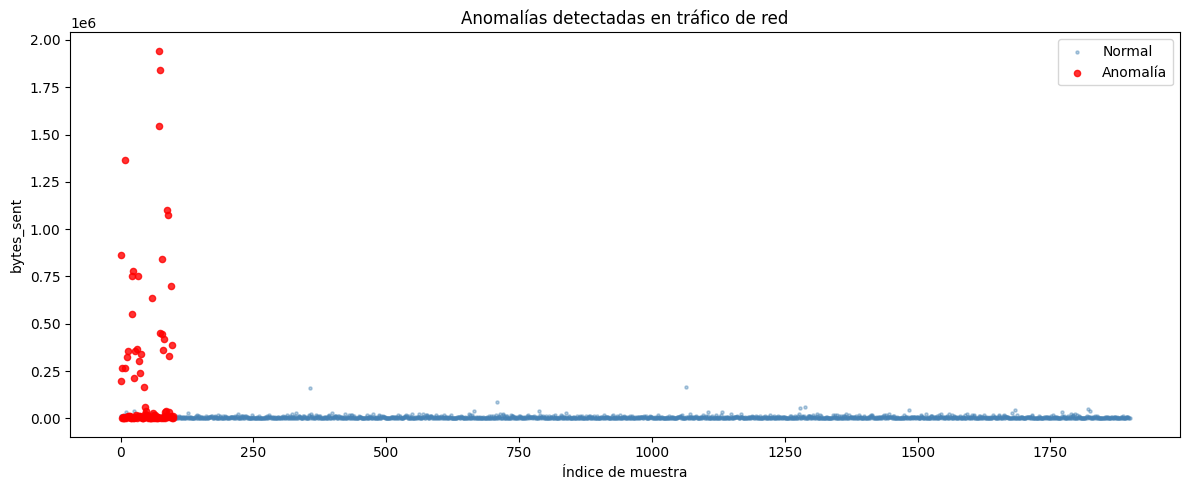

Gráfico guardado: anomaly_detection.png


In [2]:
# CORRECCIÓN: reimport explícito para que la celda sea independiente
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Cargar y escalar datos
data_if = pd.read_csv('network_traffic.csv').dropna()
if 'protocol' in data_if.columns:
    data_if['protocol'] = LabelEncoder().fit_transform(data_if['protocol'])

feature_cols_if = ['bytes_sent', 'bytes_recv', 'duration', 'src_port']
feature_cols_if = [c for c in feature_cols_if if c in data_if.columns]

scaler_if = MinMaxScaler()
scaled_if = scaler_if.fit_transform(data_if[feature_cols_if])

# 2. Entrenar Isolation Forest
# contamination: fracción esperada de anomalías (5%)
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1  # usar todos los núcleos disponibles
)
model.fit(scaled_if)

# 3. Predicción
# 1 = normal  |  -1 = anomalía
predictions = model.predict(scaled_if)
scores = model.decision_function(scaled_if)  # puntuación de anomalía

data_if = data_if.copy()
data_if['anomaly'] = predictions
data_if['anomaly_score'] = scores

# 4. Resultados
anomalous = data_if[data_if['anomaly'] == -1]
normal    = data_if[data_if['anomaly'] ==  1]

print(f'Total de muestras  : {len(data_if)}')
print(f'Muestras normales  : {len(normal)}')
print(f'Anomalías detectadas: {len(anomalous)}')
print('\nTop 10 anomalías (menor puntuación = más anómalo):')
print(anomalous.sort_values('anomaly_score').head(10))

# 5. Visualización
# CORRECCIÓN: usar reset_index para alinear ejes X correctamente
normal_reset = normal.reset_index(drop=True)
plt.figure(figsize=(12, 5))
plt.scatter(range(len(normal_reset)),
            normal_reset['bytes_sent'], s=5, c='steelblue',
            alpha=0.4, label='Normal')
plt.scatter(range(len(anomalous)),
            anomalous['bytes_sent'].values, s=20, c='red',
            alpha=0.8, label='Anomalía')
plt.xlabel('Índice de muestra')
plt.ylabel('bytes_sent')
plt.title('Anomalías detectadas en tráfico de red')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150)
plt.show()
print('Gráfico guardado: anomaly_detection.png')

## 3.4 Detección de intrusiones con Autoencoder (Deep Learning)

Un **autoencoder** aprende a reconstruir entradas normales. Cuando procesa datos anómalos, el error de reconstrucción es alto, permitiendo detectar intrusiones no vistas durante el entrenamiento.

2026-05-12 08:54:22.767272: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428 (1.67 KB)

 Trainable params: 428 (1.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1546 - val_loss: 0.1433
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1321 - val_loss: 0.1170
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1027 - val_loss: 0.0844
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0703 - val_loss: 0.0543
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0452 - val_loss: 0.0358
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0319 - val_loss: 0.0276
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0261 - val_loss: 0.0235
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0228 - val_loss: 0.0206
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0200 - val_loss: 0.0179
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0174 - val_loss: 0.0154
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0149 - val_loss: 0.0128
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - val_l

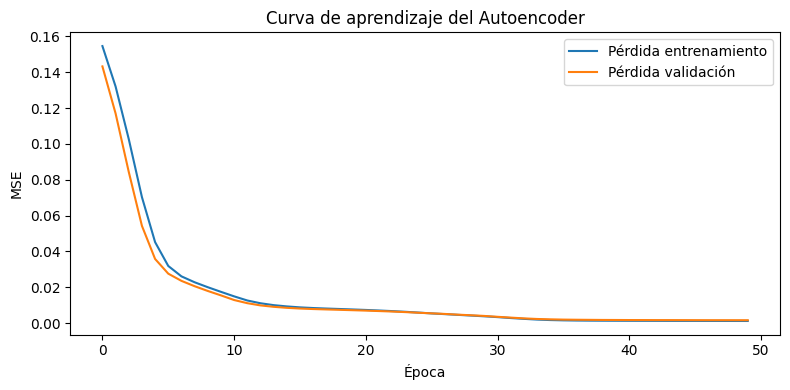

Gráfico guardado: autoencoder_loss.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# CORRECCIÓN: con TensorFlow 2.16 + Keras 3.x se importa keras directamente
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import keras
from keras import layers

# 1. Preparar datos (solo tráfico normal para entrenamiento)
data_ae = pd.read_csv('network_traffic.csv').dropna()
if 'protocol' in data_ae.columns:
    data_ae['protocol'] = LabelEncoder().fit_transform(data_ae['protocol'])

feature_cols_ae = ['bytes_sent', 'bytes_recv', 'duration', 'src_port']
feature_cols_ae = [c for c in feature_cols_ae if c in data_ae.columns]

scaler_ae = MinMaxScaler()
X = scaler_ae.fit_transform(data_ae[feature_cols_ae])

# Dividir: 80% entrenamiento, 20% prueba
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# 2. Definir arquitectura del autoencoder
input_dim = X.shape[1]

def build_autoencoder(input_dim: int, encoding_dim: int = 8):
    """Construye un autoencoder simétrico."""
    # Codificador
    inp     = keras.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation='relu')(inp)
    encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
    # Decodificador
    decoded = layers.Dense(16, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = keras.Model(inp, decoded, name='autoencoder')
    encoder     = keras.Model(inp, encoded, name='encoder')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(input_dim)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# 3. Entrenar
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

# 4. Calcular error de reconstrucción
X_pred     = autoencoder.predict(X_test)
mse_err    = np.mean(np.power(X_test - X_pred, 2), axis=1)

# Umbral: percentil 95 del error en datos de entrenamiento
X_train_pred = autoencoder.predict(X_train)
train_mse    = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
threshold    = np.percentile(train_mse, 95)
print(f'Umbral de detección: {threshold:.6f}')

# Clasificar anomalías
anomalies_detected = mse_err > threshold
print(f'Anomalías detectadas en test: {anomalies_detected.sum()}')

# 5. Curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Curva de aprendizaje del Autoencoder')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_loss.png', dpi=150)
plt.show()
print('Gráfico guardado: autoencoder_loss.png')